# Propeller Calibration

Workflow:
1. Select a set of calibration run files (one per target velocity).
2. For each file, automatically detect the constant-velocity plateau and compute the mean rev/s.
3. Fit the chosen calibration function: linear, polynomial (degree n), power law, or logarithmic.
4. Compare all fits, inspect residuals, and select the best one.
5. Write a calibration JSON file compatible with the Velocimeter app.

In [1]:
import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import date
from scipy import stats, optimize
from tkinter import Tk, filedialog

## 1. Select calibration files

In [2]:
USE_FILE_DIALOG = True   # set False and fill FILE_PATHS manually
FILE_PATHS = []          # e.g. ["synthetic_data/Calibration_IMP1_0_3_mps.txt", ...]

if USE_FILE_DIALOG:
    root = Tk()
    root.withdraw()
    root.attributes("-topmost", True)
    selected = filedialog.askopenfilenames(
        title="Select calibration run files",
        filetypes=[("Text files", "*.txt"), ("All files", "*.*")],
        initialdir=Path("synthetic_data"),
    )
    root.destroy()
    FILE_PATHS = list(selected)

print(f"Selected {len(FILE_PATHS)} file(s):")
for p in FILE_PATHS:
    print(" ", p)

Selected 5 file(s):
  C:/Users/morenoro/OneDrive - Stichting Deltares/Documents/OMNIA/Projects_Deltares/Z_AuxiliaryInfo/Sensors/ESP_FlowmeterMoulinette/OTT_ESPvelocimeter/calibration/synthetic_data_test1/Calibration_IMP1_Synthetic_0_3_mps.txt
  C:/Users/morenoro/OneDrive - Stichting Deltares/Documents/OMNIA/Projects_Deltares/Z_AuxiliaryInfo/Sensors/ESP_FlowmeterMoulinette/OTT_ESPvelocimeter/calibration/synthetic_data_test1/Calibration_IMP1_Synthetic_0_6_mps.txt
  C:/Users/morenoro/OneDrive - Stichting Deltares/Documents/OMNIA/Projects_Deltares/Z_AuxiliaryInfo/Sensors/ESP_FlowmeterMoulinette/OTT_ESPvelocimeter/calibration/synthetic_data_test1/Calibration_IMP1_Synthetic_0_9_mps.txt
  C:/Users/morenoro/OneDrive - Stichting Deltares/Documents/OMNIA/Projects_Deltares/Z_AuxiliaryInfo/Sensors/ESP_FlowmeterMoulinette/OTT_ESPvelocimeter/calibration/synthetic_data_test1/Calibration_IMP1_Synthetic_1_2_mps.txt
  C:/Users/morenoro/OneDrive - Stichting Deltares/Documents/OMNIA/Projects_Deltares/Z_Au

## 2. Parse & load files

In [3]:
def parse_filename(path):
    """
    Expected: Calibration_<PROP>_<V_int>_<V_dec>_mps.txt
    e.g. Calibration_IMP1_0_3_mps.txt  →  prop='IMP1', v_target=0.3
    """
    stem = Path(path).stem
    m = re.match(r"Calibration_(.+?)_(\d+)_(\d+)_mps", stem)
    if not m:
        raise ValueError(f"Cannot parse filename: {stem}")
    return m.group(1), float(f"{m.group(2)}.{m.group(3)}")


def load_run(path):
    return pd.read_csv(path, comment="#", header=0,
                       names=["timestamp", "elapsed_s", "value"])


for p in FILE_PATHS[:1]:
    prop_id, v_target = parse_filename(p)
    df = load_run(p)
    print(f"Propeller: {prop_id}   Target: {v_target} m/s   Rows: {len(df)}")
    display(df.head())

Propeller: IMP1_Synthetic   Target: 0.3 m/s   Rows: 31


,timestamp,elapsed_s,value
0,2026-04-01 10:00:00,0.0,0.038
1,2026-04-01 10:00:01,1.0,0.357
2,2026-04-01 10:00:02,2.0,1.627
3,2026-04-01 10:00:03,3.0,2.750
4,2026-04-01 10:00:04,4.0,3.596


## 3. Extract plateau mean rev/s

Trim `RAMP_FRACTION` from each end of every run, then take the plateau mean.

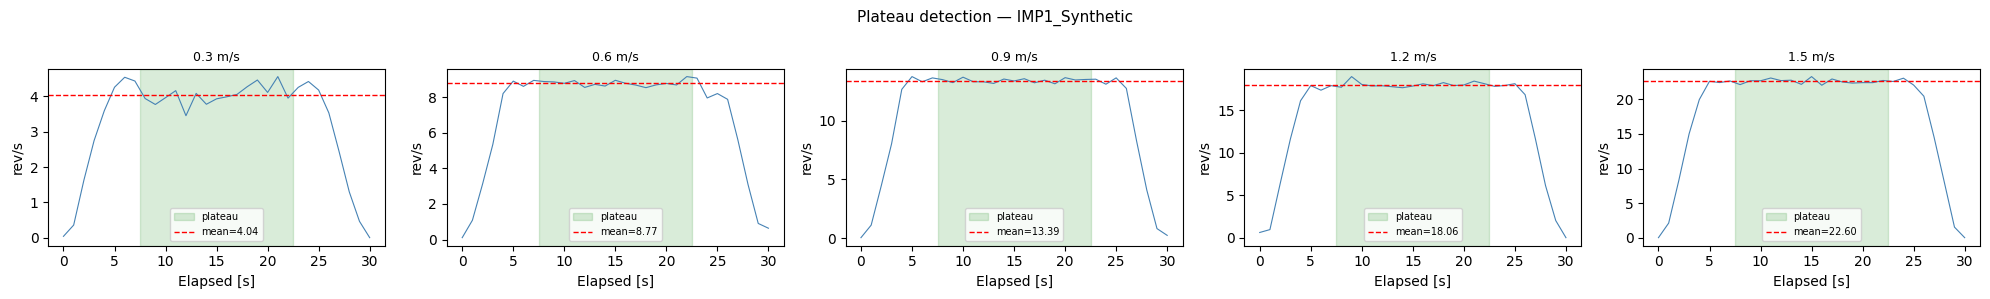

,prop_id,v_target,mean_revs,std_revs,n_plateau
0,IMP1_Synthetic,0.3,4.035667,0.274140,15
1,IMP1_Synthetic,0.6,8.772933,0.164059,15
2,IMP1_Synthetic,0.9,13.387800,0.174258,15
3,IMP1_Synthetic,1.2,18.061067,0.331359,15
4,IMP1_Synthetic,1.5,22.596467,0.354807,15


In [4]:
RAMP_FRACTION = 0.25   # fraction of total run to trim from each end

results = []
fig, axes = plt.subplots(1, len(FILE_PATHS), figsize=(4 * len(FILE_PATHS), 3), sharey=False)
if len(FILE_PATHS) == 1:
    axes = [axes]

for ax, path in zip(axes, FILE_PATHS):
    prop_id, v_target = parse_filename(path)
    df = load_run(path)
    t_total = df["elapsed_s"].max()
    t_lo, t_hi = t_total * RAMP_FRACTION, t_total * (1 - RAMP_FRACTION)
    plateau = df[(df["elapsed_s"] >= t_lo) & (df["elapsed_s"] <= t_hi)]
    mean_revs = plateau["value"].mean()

    results.append({"prop_id": prop_id, "v_target": v_target,
                    "mean_revs": mean_revs, "std_revs": plateau["value"].std(),
                    "n_plateau": len(plateau)})

    ax.plot(df["elapsed_s"], df["value"], lw=0.8, color="steelblue")
    ax.axvspan(t_lo, t_hi, alpha=0.15, color="green", label="plateau")
    ax.axhline(mean_revs, color="red", ls="--", lw=1, label=f"mean={mean_revs:.2f}")
    ax.set_title(f"{v_target} m/s", fontsize=9)
    ax.set_xlabel("Elapsed [s]")
    ax.set_ylabel("rev/s")
    ax.legend(fontsize=7)

plt.suptitle(f"Plateau detection — {prop_id}", fontsize=11)
plt.tight_layout()
plt.show()

df_results = pd.DataFrame(results)
display(df_results)

## 4. Fit calibration functions

Available models — all map **rev/s → m/s**:

| Key | Formula | Good for |
|-----|---------|----------|
| `linear` | `v = a + b·n` | Most OTT propellers (default) |
| `poly2` | `v = a + b·n + c·n²` | Slight nonlinearity at high speed |
| `poly3` | `v = a + b·n + c·n² + d·n³` | Strong nonlinearity |
| `polyN` | degree N polynomial (set `POLY_DEGREE`) | Any degree |
| `power` | `v = a·n^b` | Sensors with zero offset near zero |
| `log`   | `v = a + b·ln(n)` | Logarithmic response |

Set `FIT_MODELS` to the subset you want to compare, and `SELECTED_MODEL` for the one to export.

In [8]:
# ── User choices ──────────────────────────────────────────────────────────────
FIT_MODELS     = ["linear", "poly2", "poly3", "power"]  # models to compare
SELECTED_MODEL = "poly2"   # model to write to the JSON
POLY_DEGREE    = 4           # used only when FIT_MODELS includes 'polyN'
# ─────────────────────────────────────────────────────────────────────────────

x = df_results["mean_revs"].values
y = df_results["v_target"].values


def r2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - ss_res / ss_tot if ss_tot > 0 else np.nan


def fit_model(name, x, y, poly_degree=POLY_DEGREE):
    """
    Returns dict with keys:
      name, params, r2, y_pred,
      function_str (Python eval-able, variable = v),
      params_val   (dict for JSON),
      label        (human-readable)
    """
    result = {"name": name}

    if name == "linear":
        slope, intercept, r, *_ = stats.linregress(x, y)
        result["params"]       = {"a": intercept, "b": slope}
        result["function_str"] = "a + b * v"
        result["label"]        = f"v = {intercept:.3f} + {slope:.3f}·n"
        result["y_pred"]       = intercept + slope * x

    elif name in ("poly2", "poly3", "polyN"):
        deg = {"poly2": 2, "poly3": 3, "polyN": poly_degree}[name]
        coeffs = np.polyfit(x, y, deg)  # highest degree first
        coeffs = coeffs[::-1]           # reorder: coeffs[0]=a, coeffs[1]=b, ...
        letters = "abcdefghijklmnopqrstuvwxyz"
        params   = {letters[i]: float(c) for i, c in enumerate(coeffs)}
        terms    = " + ".join(f"{letters[i]} * v**{i}" if i > 1
                              else (f"{letters[i]} * v" if i == 1 else letters[i])
                              for i in range(len(coeffs)))
        label_terms = " + ".join(
            f"{c:.3f}" if i == 0 else
            (f"{c:.3f}·n" if i == 1 else f"{c:.3f}·n^{i}")
            for i, c in enumerate(coeffs)
        )
        result["params"]       = params
        result["function_str"] = terms
        result["label"]        = f"v = {label_terms}  (deg {deg})"
        result["y_pred"]       = np.polyval(coeffs[::-1], x)

    elif name == "power":
        # v = a * n^b  (requires x > 0)
        try:
            popt, _ = optimize.curve_fit(lambda n, a, b: a * n**b, x, y,
                                         p0=[0.1, 1.0], maxfev=5000)
            a, b = popt
            result["params"]       = {"a": float(a), "b": float(b)}
            result["function_str"] = "a * v**b"
            result["label"]        = f"v = {a:.3f}·n^{b:.3f}"
            result["y_pred"]       = a * x**b
        except Exception as e:
            print(f"Power fit failed: {e}")
            return None

    elif name == "log":
        # v = a + b*ln(n)  (requires x > 0)
        try:
            popt, _ = optimize.curve_fit(lambda n, a, b: a + b * np.log(n), x, y, p0=[0, 1])
            a, b = popt
            result["params"]       = {"a": float(a), "b": float(b)}
            result["function_str"] = "a + b * log(v)"
            result["label"]        = f"v = {a:.3f} + {b:.3f}·ln(n)"
            result["y_pred"]       = a + b * np.log(x)
        except Exception as e:
            print(f"Log fit failed: {e}")
            return None

    else:
        raise ValueError(f"Unknown model: {name}")

    result["r2"]        = r2_score(y, result["y_pred"])
    result["params_val"] = {k: round(v, 8) for k, v in result["params"].items()}
    return result


fits = {}
print(f"{'Model':<10}  {'R²':>8}  Formula")
print("-" * 60)
for name in FIT_MODELS:
    f = fit_model(name, x, y)
    if f:
        fits[name] = f
        marker = "  ← selected" if name == SELECTED_MODEL else ""
        print(f"{name:<10}  {f['r2']:>8.6f}  {f['label']}{marker}")

Model             R²  Formula
------------------------------------------------------------
linear      0.999951  v = 0.036 + 0.065·n
poly2       0.999990  v = 0.046 + 0.063·n + 0.000·n^2  (deg 2)  ← selected
poly3       0.999991  v = 0.044 + 0.063·n + 0.000·n^2 + 0.000·n^3  (deg 3)
power       0.999696  v = 0.076·n^0.957


## 5. Plot: calibration curves + residuals

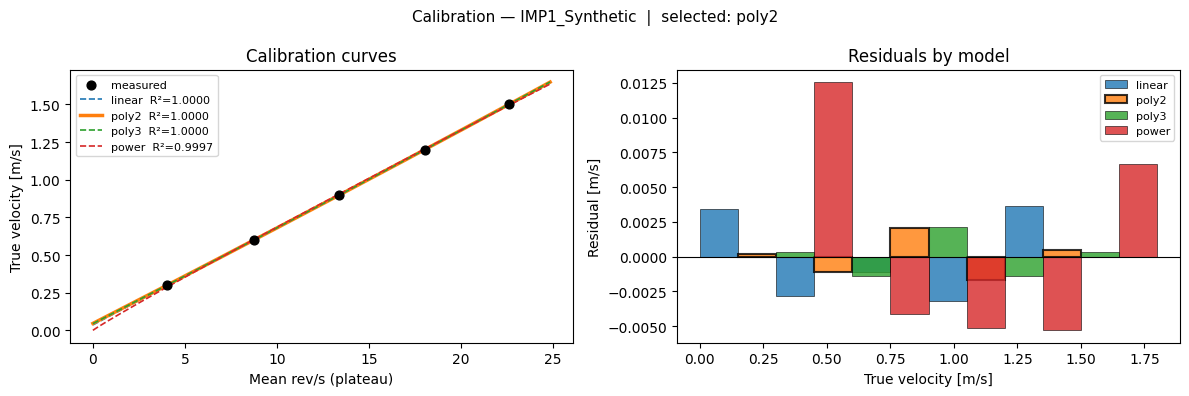

In [9]:
colors = plt.cm.tab10.colors
x_plot = np.linspace(0, x.max() * 1.1, 200)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.scatter(x, y, color="black", zorder=10, s=40, label="measured")
for i, (name, f) in enumerate(fits.items()):
    lw = 2.5 if name == SELECTED_MODEL else 1.2
    ls = "-"  if name == SELECTED_MODEL else "--"
    # evaluate on plot grid
    if name == "linear":
        y_plot = f["params"]["a"] + f["params"]["b"] * x_plot
    elif name in ("poly2", "poly3", "polyN"):
        coeffs = [f["params"][k] for k in sorted(f["params"])]
        y_plot = np.polyval(coeffs[::-1], x_plot)
    elif name == "power":
        y_plot = f["params"]["a"] * x_plot ** f["params"]["b"]
    elif name == "log":
        y_plot = f["params"]["a"] + f["params"]["b"] * np.log(np.clip(x_plot, 1e-9, None))
    ax1.plot(x_plot, y_plot, color=colors[i], lw=lw, ls=ls,
             label=f"{name}  R²={f['r2']:.4f}")

ax1.set_xlabel("Mean rev/s (plateau)")
ax1.set_ylabel("True velocity [m/s]")
ax1.set_title("Calibration curves")
ax1.legend(fontsize=8)

# Residuals
n_models = len(fits)
bar_width = 0.6 / n_models
offsets = np.linspace(-0.3 + bar_width/2, 0.3 - bar_width/2, n_models)
for i, (name, f) in enumerate(fits.items()):
    residuals = y - f["y_pred"]
    lw = 1.5 if name == SELECTED_MODEL else 0.5
    ax2.bar(y + offsets[i], residuals, width=bar_width,
            color=colors[i], label=name, alpha=0.8, linewidth=lw, edgecolor="k")

ax2.axhline(0, color="black", lw=0.8)
ax2.set_xlabel("True velocity [m/s]")
ax2.set_ylabel("Residual [m/s]")
ax2.set_title("Residuals by model")
ax2.legend(fontsize=8)

plt.suptitle(f"Calibration — {df_results['prop_id'].iloc[0]}  |  selected: {SELECTED_MODEL}",
             fontsize=11)
plt.tight_layout()
plt.show()

## 6. Write calibration JSON

Exports `SELECTED_MODEL` to a JSON file readable by the Velocimeter app.  
The `function` string uses `v` as the sensor input (rev/s) and `log` for natural log.

In [11]:
PROP_ID       = df_results["prop_id"].iloc[0]
OUTPUT_FOLDER = Path("../calibrationfiles")
OUTPUT_FOLDER.mkdir(parents=True, exist_ok=True)

sel = fits[SELECTED_MODEL]

cal = {
    "impeler":    PROP_ID,
    "function":   sel["function_str"],
    "params_val": sel["params_val"],
    "metadata": {
        "date":           str(date.today()),
        "user":           "",
        "model":          SELECTED_MODEL,
        "description":    f"{SELECTED_MODEL} calibration for {PROP_ID}. "
                           f"Fit on {len(df_results)} velocities. R²={sel['r2']:.4f}.",
        "r2":             round(sel["r2"], 6),
        "n_points":       len(df_results),
        "velocities_mps": df_results["v_target"].tolist(),
        "all_fits_r2":    {n: round(f["r2"], 6) for n, f in fits.items()},
    },
}

out_path = OUTPUT_FOLDER / f"calibration_{PROP_ID}_{SELECTED_MODEL}.json"
with open(out_path, "w") as f:
    json.dump(cal, f, indent=2)

print(f"Written: {out_path}")
print(json.dumps(cal, indent=2))

Written: ..\calibrationfiles\calibration_IMP1_Synthetic_poly2.json
{
  "impeler": "IMP1_Synthetic",
  "function": "a + b * v + c * v**2",
  "params_val": {
    "a": 0.04567034,
    "b": 0.06266765,
    "c": 7.398e-05
  },
  "metadata": {
    "date": "2026-04-05",
    "user": "",
    "model": "poly2",
    "description": "poly2 calibration for IMP1_Synthetic. Fit on 5 velocities. R\u00b2=1.0000.",
    "r2": 0.99999,
    "n_points": 5,
    "velocities_mps": [
      0.3,
      0.6,
      0.9,
      1.2,
      1.5
    ],
    "all_fits_r2": {
      "linear": 0.999951,
      "poly2": 0.99999,
      "poly3": 0.999991,
      "power": 0.999696
    }
  }
}
